In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Preprocessed_Dataset.csv')

In [3]:
display(df.head())

,id,sentence,security,reliability,NFR_boolean,cleaned_sentence
0,CCHIT Certified 2011 Ambulatory EHR Criteria 2...,The system shall create a single patient recor...,0,0,0,system shall create single patient record patient
1,CCHIT Certified 2011 Ambulatory EHR Criteria 2...,The system shall associate (store and link) ke...,0,0,0,system shall associate store link key identifi...
2,CCHIT Certified 2011 Ambulatory EHR Criteria 2...,The system shall provide the ability to store ...,0,0,0,system shall provide ability store one identif...
3,CCHIT Certified 2011 Ambulatory EHR Criteria 2...,The system shall provide a field which will id...,0,0,0,system shall provide field identify patient ex...
4,CCHIT Certified 2011 Ambulatory EHR Criteria 2...,The system shall provide the ability to merge ...,0,0,0,system shall provide ability merge patient inf...


In [4]:
print(f"Rows before dropping NaNs: {len(df)}")
df = df.dropna(subset=['cleaned_sentence'])
print(f"Rows after dropping NaNs: {len(df)}")

Rows before dropping NaNs: 11440
Rows after dropping NaNs: 11375


In [5]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')

In [6]:
X = tfidf.fit_transform(df['cleaned_sentence'])

In [7]:
feature_names = tfidf.get_feature_names_out()
print(f"\nTotal unique features (words/phrases) identified: {len(feature_names)}")
print("Sample features:", feature_names[100:110])


Total unique features (words/phrases) identified: 5000
Sample features: ['accomplish' 'accomplish purpose' 'accordance' 'accordance applicable'
 'accordance certification' 'accordance paragraph' 'accordance standard'
 'accordance user' 'according' 'according applicable']


In [8]:
weights = np.asarray(X.mean(axis=0)).ravel().tolist()
weights_df = pd.DataFrame({'word': feature_names, 'avg_tfidf': weights})
weights_df = weights_df.sort_values(by='avg_tfidf', ascending=False).head(20)

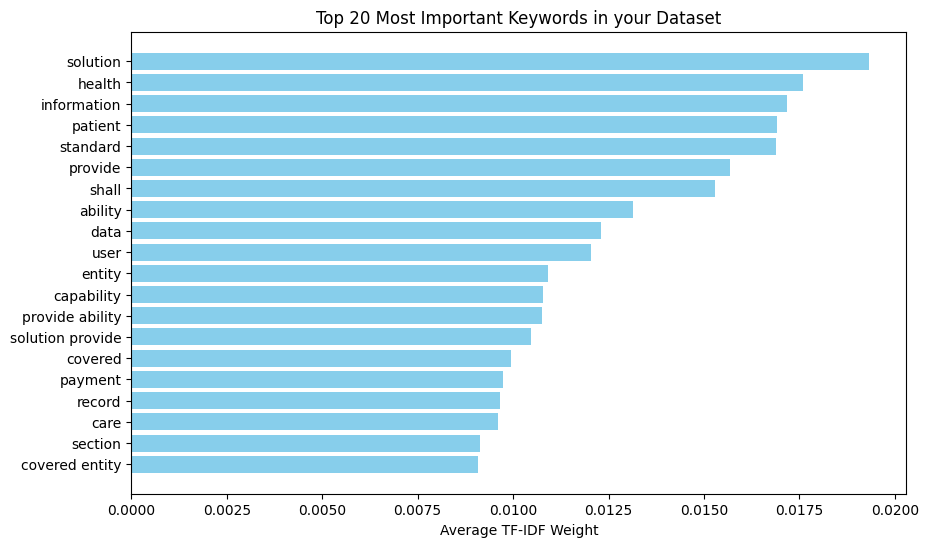

In [9]:
plt.figure(figsize=(10, 6))
plt.barh(weights_df['word'], weights_df['avg_tfidf'], color='skyblue')
plt.xlabel('Average TF-IDF Weight')
plt.title('Top 20 Most Important Keywords in your Dataset')
plt.gca().invert_yaxis()
plt.show()

In [10]:
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

In [11]:
joblib.dump(X, 'X_features.pkl')
joblib.dump(df['NFR_boolean'], 'y_nfr_labels.pkl')
joblib.dump(df['security'], 'y_security_labels.pkl')
joblib.dump(df['reliability'], 'y_reliability_labels.pkl')

['y_reliability_labels.pkl']

In [12]:
print("\nFeature Engineering Complete!")
print("Saved: tfidf_vectorizer.pkl, X_features.pkl, and label files.")


Feature Engineering Complete!
Saved: tfidf_vectorizer.pkl, X_features.pkl, and label files.
